# Appointment Behavior Functions

This notebook isolates the patient-behavior functions used in the first simulator and plots them directly, without running the appointment simulation itself.

The horizontal axis is always the original offered delay `\tau`.


In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd().resolve()
if not (ROOT / "appointment_simulation").exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

for module_name in list(sys.modules):
    if module_name == "appointment_simulation" or module_name.startswith("appointment_simulation."):
        del sys.modules[module_name]

from IPython.display import display

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from appointment_simulation import (
    PatientClassConfig,
    behavior_profile_frame,
    green_savin_no_show,
    split_two_class_arrival_rates,
    step_balking,
)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)


## Behavior presets

Use the active preset to switch between the default step-balking assumptions and a stricter balking alternative. The total arrival rate `\lambda` and share `p` are only used to instantiate the two patient classes consistently.


In [2]:
BASE_CLASS_SHARE = 7 / 12

BEHAVIOR_PRESETS = {
    "baseline": {
        "horizon_days": 15,
        "total_lambda": 0.24,
        "class_1_share": BASE_CLASS_SHARE,
        "balk_variant": "baseline",
        "notes": "Baseline step balking with source-aligned no-show curves.",
    },
    "strict_balking": {
        "horizon_days": 15,
        "total_lambda": 0.24,
        "class_1_share": BASE_CLASS_SHARE,
        "balk_variant": "strict",
        "notes": "Earlier balk thresholds and higher balk levels.",
    },
}

ACTIVE_PRESET = "baseline"

pd.DataFrame(
    [
        {
            "preset": name,
            "horizon_days": preset["horizon_days"],
            "lambda_total": preset["total_lambda"],
            "p": preset["class_1_share"],
            "lambda_1_derived": preset["total_lambda"] * preset["class_1_share"],
            "lambda_2_derived": preset["total_lambda"] * (1 - preset["class_1_share"]),
            "balk_variant": preset["balk_variant"],
            "notes": preset["notes"],
        }
        for name, preset in BEHAVIOR_PRESETS.items()
    ]
).set_index("preset")


,horizon_days,lambda_total,p,lambda_1_derived,lambda_2_derived,balk_variant,notes
preset,,,,,,,
baseline,15,0.24,0.583333,0.14,0.1,baseline,Baseline step balking with source-aligned no-s...
strict_balking,15,0.24,0.583333,0.14,0.1,strict,Earlier balk thresholds and higher balk levels.


In [3]:
def make_classes(total_lambda=0.24, class_1_share=7 / 12, balk_variant="baseline"):
    lambda_1, lambda_2 = split_two_class_arrival_rates(total_lambda, class_1_share)

    if balk_variant == "baseline":
        balk_1 = step_balking(threshold=4, low_delay_probability=0.05, high_delay_probability=0.60)
        balk_2 = step_balking(threshold=3, low_delay_probability=0.08, high_delay_probability=0.70)
    else:
        balk_1 = step_balking(threshold=2, low_delay_probability=0.10, high_delay_probability=0.85)
        balk_2 = step_balking(threshold=2, low_delay_probability=0.12, high_delay_probability=0.90)

    return [
        PatientClassConfig(
            class_id=1,
            label="class_1 (MRI-like)",
            arrival_rate=lambda_1,
            balk_probability=balk_1,
            cancel_probability=0.10,
            no_show_probability=green_savin_no_show(gamma_0=0.01, gamma_max=0.31, sensitivity=50.0),
        ),
        PatientClassConfig(
            class_id=2,
            label="class_2 (mental-health-like)",
            arrival_rate=lambda_2,
            balk_probability=balk_2,
            cancel_probability=0.06,
            no_show_probability=green_savin_no_show(gamma_0=0.15, gamma_max=0.51, sensitivity=9.0),
        ),
    ]


ACTIVE_BEHAVIOR_CONFIG = BEHAVIOR_PRESETS[ACTIVE_PRESET]
BASE_CLASSES = make_classes(
    total_lambda=ACTIVE_BEHAVIOR_CONFIG["total_lambda"],
    class_1_share=ACTIVE_BEHAVIOR_CONFIG["class_1_share"],
    balk_variant=ACTIVE_BEHAVIOR_CONFIG["balk_variant"],
)
BEHAVIOR_DF = behavior_profile_frame(BASE_CLASSES, horizon_days=ACTIVE_BEHAVIOR_CONFIG["horizon_days"])

BEHAVIOR_DF


,class_id,label,tau_booked,balk_probability,no_show_probability,eventual_cancel_probability,daily_cancel_probability
0,1,class_1 (MRI-like),0,0.05,0.010000,0.00,0.000000
1,1,class_1 (MRI-like),1,0.05,0.015940,0.10,0.100000
2,1,class_1 (MRI-like),2,0.05,0.021763,0.10,0.051317
3,1,class_1 (MRI-like),3,0.05,0.027471,0.10,0.034511
4,1,class_1 (MRI-like),4,0.60,0.033065,0.10,0.025996
5,1,class_1 (MRI-like),5,0.60,0.038549,0.10,0.020852
6,1,class_1 (MRI-like),6,0.60,0.043924,0.10,0.017407
7,1,class_1 (MRI-like),7,0.60,0.049193,0.10,0.014939
8,1,class_1 (MRI-like),8,0.60,0.054357,0.10,0.013084
9,1,class_1 (MRI-like),9,0.60,0.059419,0.10,0.011638


## Function tables

In [4]:
behavior_display_df = BEHAVIOR_DF.rename(
    columns={
        "tau_booked": "tau",
        "eventual_cancel_probability": "bar_phi_i",
        "daily_cancel_probability": "phi_i(tau)",
    }
)

display(
    behavior_display_df.pivot_table(
        index=["class_id", "label", "tau"],
        values=["balk_probability", "no_show_probability", "bar_phi_i", "phi_i(tau)"],
    ).reset_index().head(12)
)

behavior_display_df.tail(12)


,class_id,label,tau,balk_probability,bar_phi_i,no_show_probability,phi_i(tau)
0,1,class_1 (MRI-like),0,0.05,0.0,0.010000,0.000000
1,1,class_1 (MRI-like),1,0.05,0.1,0.015940,0.100000
2,1,class_1 (MRI-like),2,0.05,0.1,0.021763,0.051317
3,1,class_1 (MRI-like),3,0.05,0.1,0.027471,0.034511
4,1,class_1 (MRI-like),4,0.60,0.1,0.033065,0.025996
5,1,class_1 (MRI-like),5,0.60,0.1,0.038549,0.020852
6,1,class_1 (MRI-like),6,0.60,0.1,0.043924,0.017407
7,1,class_1 (MRI-like),7,0.60,0.1,0.049193,0.014939
8,1,class_1 (MRI-like),8,0.60,0.1,0.054357,0.013084
9,1,class_1 (MRI-like),9,0.60,0.1,0.059419,0.011638


,class_id,label,tau,balk_probability,no_show_probability,bar_phi_i,phi_i(tau)
18,2,class_2 (mental-health-like),3,0.7,0.252049,0.06,0.020414
19,2,class_2 (mental-health-like),4,0.7,0.279175,0.06,0.015350
20,2,class_2 (mental-health-like),5,0.7,0.303449,0.06,0.012299
21,2,class_2 (mental-health-like),6,0.7,0.325170,0.06,0.010260
22,2,class_2 (mental-health-like),7,0.7,0.344607,0.06,0.008800
23,2,class_2 (mental-health-like),8,0.7,0.362000,0.06,0.007705
24,2,class_2 (mental-health-like),9,0.7,0.377563,0.06,0.006851
25,2,class_2 (mental-health-like),10,0.7,0.391491,0.06,0.006168
26,2,class_2 (mental-health-like),11,0.7,0.403953,0.06,0.005609
27,2,class_2 (mental-health-like),12,0.7,0.415105,0.06,0.005143


## Function plots

In the mathematical notation, `\phi_i(\tau)` is the daily pre-appointment cancellation function. In the current prototype it is induced by an eventual cancellation level `\bar{\phi}_i`, via

$$
\phi_i(\tau)=1-(1-\bar{\phi}_i)^{1/\tau} \quad \text{for } \tau \ge 1,
$$

with `\phi_i(0)=0`. The third plot therefore shows `\phi_i(\tau)`, while the table above also shows the underlying `\bar{\phi}_i`.


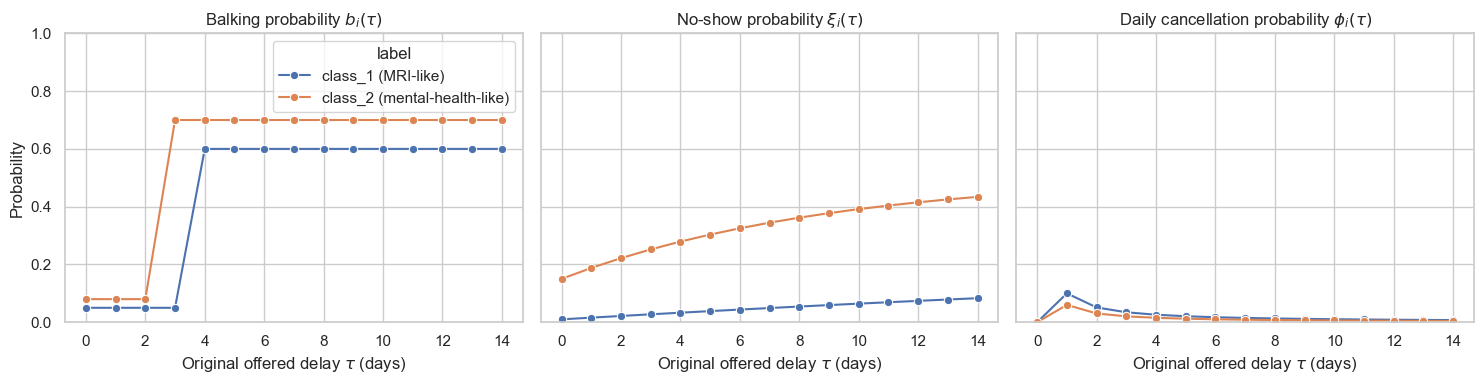

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharex=True, sharey=True)

sns.lineplot(data=behavior_display_df, x="tau", y="balk_probability", hue="label", marker="o", ax=axes[0])
axes[0].set_title(r"Balking probability $b_i(\tau)$")
axes[0].set_xlabel(r"Original offered delay $\tau$ (days)")
axes[0].set_ylabel("Probability")

sns.lineplot(data=behavior_display_df, x="tau", y="no_show_probability", hue="label", marker="o", ax=axes[1], legend=False)
axes[1].set_title(r"No-show probability $\xi_i(\tau)$")
axes[1].set_xlabel(r"Original offered delay $\tau$ (days)")
axes[1].set_ylabel("")

sns.lineplot(data=behavior_display_df, x="tau", y="phi_i(tau)", hue="label", marker="o", ax=axes[2], legend=False)
axes[2].set_title(r"Daily cancellation probability $\phi_i(\tau)$")
axes[2].set_xlabel(r"Original offered delay $\tau$ (days)")
axes[2].set_ylabel("")

for ax in axes:
    ax.set_ylim(0, 1)

plt.tight_layout()
